# Stochastic reserving: a modus operandi

Adapted from Peter England's *Example Modus Operandi* notebook in the
[StochasticReserving repository](https://github.com/DrPeterEngland/StochasticReserving) (`Python_Examples/Example_Modus_Operandi.ipynb`,
MIT licence, provided by EMC Actuarial and Analytics Ltd as an educational resource).
The fifteen steps and their rationale are his; the code uses `bayesianchainladder`, and the
commentary is paraphrased. Numbers differ slightly from the original because chainladder
extrapolates the last Mack sigma log-linearly whereas England takes the minimum of the previous
two, and because the simulation seeds differ.

**Why a modus operandi?** Quantifying reserve variability starts with understanding what drives
it, then understanding each model's characteristics and limits, and only then selecting a result.
The steps below are a guide, not a recipe.

This notebook covers the lifetime ("ultimo") view. The one-year view is a short epilogue that
points to `claims_development_result`.

## Steps 1 & 2: look at the data and fit a baseline chain ladder

,12,24,36,48,60,72,84,96,108,120
2001,"7,717","21,186","16,163","19,519","15,001","18,012","12,478","9,498","6,874","5,142"
2002,"9,133","27,150","20,034","18,489","20,261","9,912","7,082","11,276","3,871",NaN
2003,"6,835","22,437","18,458","28,646","17,759","10,675","45,659","5,509",NaN,NaN
2004,"7,059","23,055","20,484","18,636","14,425","9,473","9,826",NaN,NaN,NaN
2005,"5,131","15,738","21,053","16,755","20,545","11,631",NaN,NaN,NaN,NaN
2006,"5,682","15,799","16,696","19,639","20,613",NaN,NaN,NaN,NaN,NaN
2007,"4,204","9,365","15,356","14,629",NaN,NaN,NaN,NaN,NaN,NaN
2008,"3,106","11,237","13,301",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009,"3,617","11,710",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010,"3,157",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,12,24,36,48,60,72,84,96,108,120
2001,"7,717","28,903","45,066","64,585","79,586","97,598","110,076","119,574","126,448","131,590"
2002,"9,133","36,283","56,317","74,806","95,067","104,979","112,061","123,337","127,208",NaN
2003,"6,835","29,272","47,730","76,376","94,135","104,810","150,469","155,978",NaN,NaN
2004,"7,059","30,114","50,598","69,234","83,659","93,132","102,958",NaN,NaN,NaN
2005,"5,131","20,869","41,922","58,677","79,222","90,853",NaN,NaN,NaN,NaN
2006,"5,682","21,481","38,177","57,816","78,429",NaN,NaN,NaN,NaN,NaN
2007,"4,204","13,569","28,925","43,554",NaN,NaN,NaN,NaN,NaN,NaN
2008,"3,106","14,343","27,644",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009,"3,617","15,327",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010,"3,157",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


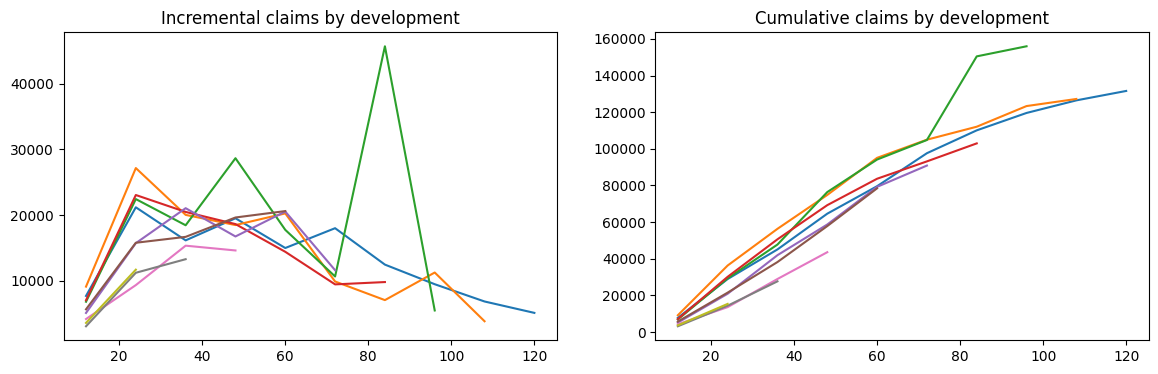

development,12,24,36,48,60,72,84,96,108
origin,,,,,,,,,
2001,4,2,1,1,1,1,1,1,1
2002,4,2,1,1,1,1,1,1,NaN
2003,4,2,2,1,1,1,1,NaN,NaN
2004,4,2,1,1,1,1,NaN,NaN,NaN
2005,4,2,1,1,1,NaN,NaN,NaN,NaN
2006,4,2,2,1,NaN,NaN,NaN,NaN,NaN
2007,3,2,2,NaN,NaN,NaN,NaN,NaN,NaN
2008,5,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Volume-weighted factors: [4.004 1.726 1.442 1.27  1.138 1.187 1.071 1.044 1.041]


,latest,reserve,ultimate
origin,,,
2001,"131,590",NaN,"131,590"
2002,"127,208","5,173","132,381"
2003,"155,978","13,523","169,501"
2004,"102,958","16,818","119,776"
2005,"90,853","34,645","125,498"
2006,"78,429","44,891","123,320"
2007,"43,554","43,454","87,008"
2008,"27,644","51,963","79,607"
2009,"15,327","60,876","76,203"


Total reserve: 331,038


In [1]:
import numpy as np
import pandas as pd
import chainladder as cl
import matplotlib.pyplot as plt

from bayesianchainladder import (
    CorrelatedBootstrapChainLadder,
    MackBootstrap,
    claims_development_result,
    link_ratio_sensitivity,
    load_england_sample,
    mack_analytic_rmsep,
    plot_fan_chart,
    plot_scaled_residuals,
    plot_sensitivity_heatmap,
    top_influential,
)

pd.options.display.float_format = "{:,.0f}".format
tri = load_england_sample("liability")
incremental = tri.cum_to_incr().to_frame(origin_as_datetime=False)
display(incremental)
display(tri.to_frame(origin_as_datetime=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
incremental.T.plot(ax=axes[0], title="Incremental claims by development", legend=False)
tri.to_frame(origin_as_datetime=False).T.plot(ax=axes[1], title="Cumulative claims by development", legend=False)
plt.show()

dev = cl.Development().fit_transform(tri)
link_ratios = (tri.values[0, 0, :, 1:] / tri.values[0, 0, :, :-1])
display(pd.DataFrame(link_ratios, index=tri.origin.year, columns=tri.development[:-1]).round(3))
print("Volume-weighted factors:", np.round(dev.ldf_.values.flatten(), 3))
cl_result = cl.Chainladder().fit(dev)
display(pd.DataFrame({"latest": tri.latest_diagonal.values[0, 0, :, 0],
                      "reserve": cl_result.ibnr_.values[0, 0, :, 0],
                      "ultimate": cl_result.ultimate_.values[0, 0, :, 0]}, index=tri.origin.year))
print("Total reserve:", f"{float(np.nansum(cl_result.ibnr_.values)):,.0f}")

**Commentary.** The incremental graph shows a large payment at development period 7 for origin
period 3 (2003). It produces a large link ratio between development periods 6 and 7 for that
origin, which reverses the otherwise decreasing pattern of the volume-weighted factors at that
point. Including every ratio gives a total reserve of about 331,000.

## Step 3: Mack's model applied analytically

In [2]:
mack = mack_analytic_rmsep(tri)
display(mack.to_frame().style.format({"reserve": "{:,.0f}", "sd": "{:,.0f}", "cov": "{:.1%}"}))

,reserve,sd,cov
2001,0,0,nan%
2002,"5,173","5,104",98.7%
2003,"13,523","7,037",52.0%
2004,"16,818","7,284",43.3%
2005,"34,645","22,494",64.9%
2006,"44,891","23,081",51.4%
2007,"43,454","19,606",45.1%
2008,"51,963","19,984",38.5%
2009,"60,876","22,646",37.2%
2010,"59,695","21,779",36.5%


**Commentary.** A coefficient of variation around 22% on the total reserve is high for a
triangle whose cumulative development looks stable, so something specific is driving it.

## Step 4: residuals and Mack's sigma

Mack sigma by development ratio: [26.8  31.1  20.79 15.95 14.52 54.59 12.29  6.43  6.43]


development,12,24,36,48,60,72,84,96,108
origin,,,,,,,,,
2001,-1,-1,-0,-1,2,-0,0,1,-0
2002,-0,-1,-1,-0,-1,-1,1,-1,NaN
2003,1,-1,2,-1,-1,2,-1,NaN,NaN
2004,1,-0,-1,-1,-1,-1,NaN,NaN,NaN
2005,0,1,-0,1,0,NaN,NaN,NaN,NaN
2006,-1,0,1,1,NaN,NaN,NaN,NaN,NaN
2007,-2,2,1,NaN,NaN,NaN,NaN,NaN,NaN
2008,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


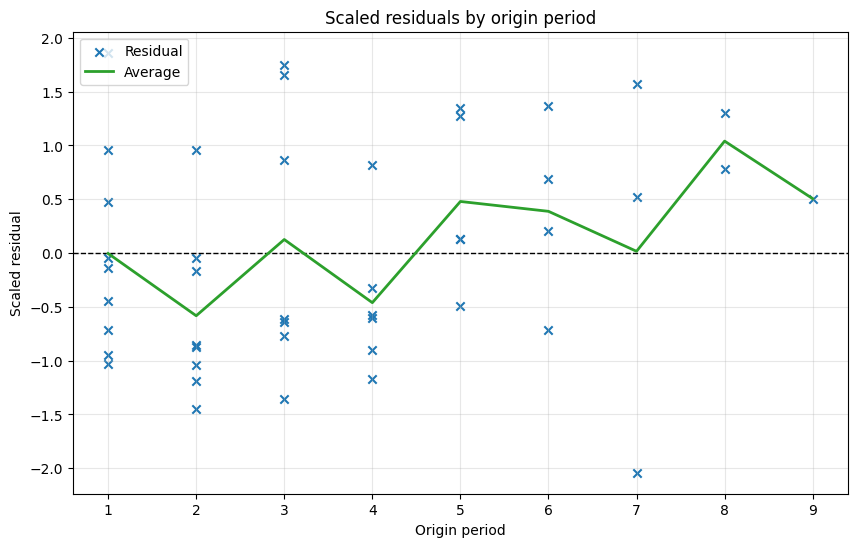

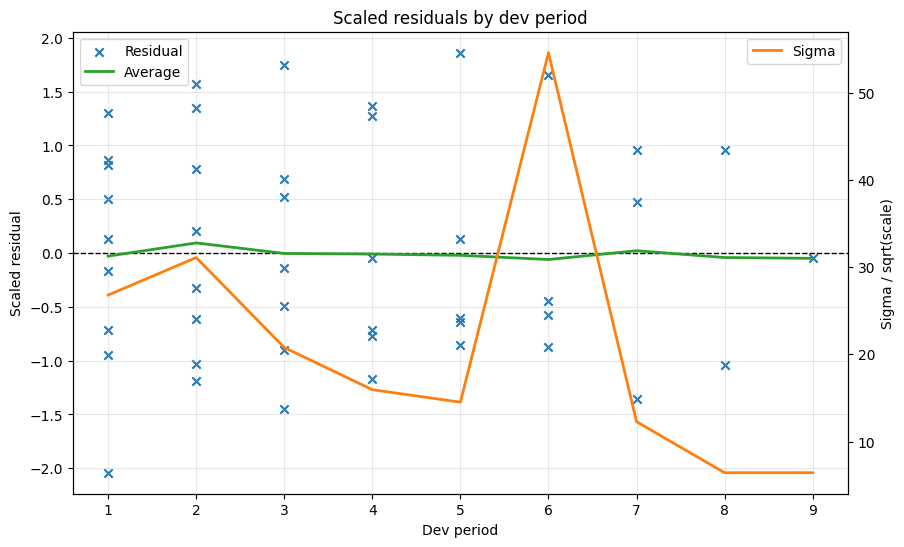

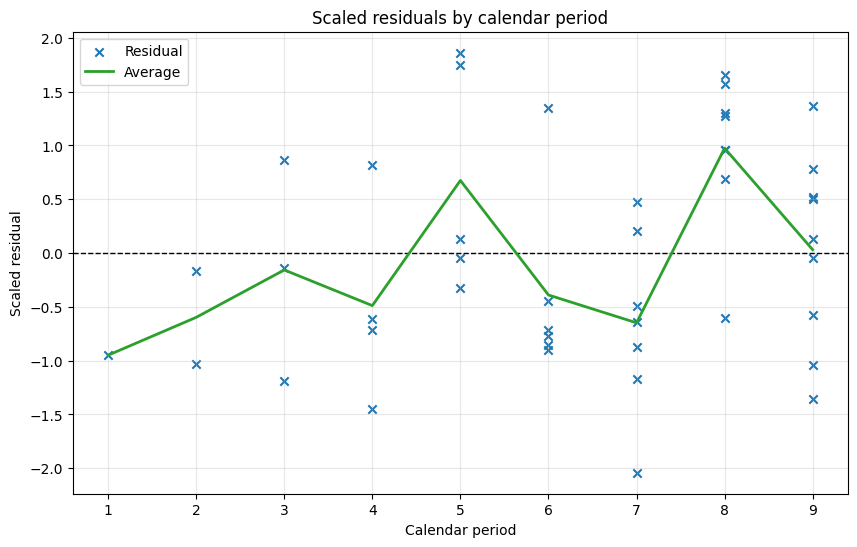

In [3]:
boot_all = MackBootstrap(n_sims=10_000, random_seed=100).fit(tri)
sigma_original = boot_all.sigma_.copy()
print("Mack sigma by development ratio:", np.round(sigma_original, 2))
display(pd.DataFrame(boot_all.scaled_residuals_, index=tri.origin.year, columns=tri.development[:-1]).round(2))
for by in ("origin", "dev", "calendar"):
    plot_scaled_residuals(boot_all.scaled_residuals_, by=by, sigma=sigma_original)
    plt.show()

**Commentary.** Sigma is the root mean square of the bias-adjusted unscaled residuals in each
development period, so one large residual inflates it. Here sigma spikes at development ratio 6
(the 72->84 month ratio), driven by origin 2003. Scaled residuals should look like i.i.d. standard
normals: pattern-free by origin, development and calendar period, with roughly 95% inside ±2.

## Step 5: bootstrap Mack's model with all ratios included

,mean,std,cov,min,0.5%,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.5%,max
2001,0,0,nan,0,0,0,0,0,0,0,0,0,0,0,0,0
2002,"5,155","3,251",1,"-7,038","-3,092","-2,288",-193,983,"2,967","5,137","7,386","9,309","10,517","12,689","13,589","17,278"
2003,"13,526","5,100",0,"-5,713",433,"1,781","5,178","7,018","10,069","13,498","16,991","20,155","21,922","25,484","26,654","33,585"
2004,"16,949","6,284",0,"-5,119","1,255","2,828","6,743","9,030","12,666","16,888","21,193","25,070","27,397","32,099","33,687","39,901"
2005,"34,605","22,293",1,"-39,439","-16,589","-12,795",-545,"6,315","19,235","33,672","49,210","63,697","72,674","90,035","96,153","136,398"
2006,"44,673","22,810",1,"-27,445","-9,029","-4,401","8,821","16,292","28,646","43,615","59,370","74,280","83,932","102,206","108,487","142,686"
2007,"43,416","19,251",0,"-11,017",-213,"3,005","13,791","19,686","29,989","42,194","55,592","68,931","76,704","92,813","98,144","133,620"
2008,"52,272","19,985",0,"-4,010","8,630","13,007","21,935","27,532","38,204","50,862","65,107","78,600","87,182","103,971","111,198","137,054"
2009,"60,988","22,389",0,-492,"12,974","16,547","27,409","33,950","44,976","58,985","75,033","90,903","101,206","121,095","127,303","156,938"
2010,"59,260","21,701",0,"3,060","15,762","19,454","27,843","33,282","43,371","57,102","72,903","88,286","97,924","118,813","126,398","172,493"


,mean,std,cov,min,0.5%,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.5%,max
2001,"131,590",0,0,"131,590","131,590","131,590","131,590","131,590","131,590","131,590","131,590","131,590","131,590","131,590","131,590","131,590"
2002,"132,363","3,251",0,"120,170","124,116","124,920","127,015","128,191","130,175","132,345","134,594","136,517","137,725","139,897","140,797","144,486"
2003,"169,504","5,100",0,"150,265","156,411","157,759","161,156","162,996","166,047","169,476","172,969","176,133","177,900","181,462","182,632","189,563"
2004,"119,907","6,284",0,"97,839","104,213","105,786","109,701","111,988","115,624","119,846","124,151","128,028","130,355","135,057","136,645","142,859"
2005,"125,458","22,293",0,"51,414","74,264","78,058","90,308","97,168","110,088","124,525","140,063","154,550","163,527","180,888","187,006","227,251"
2006,"123,102","22,810",0,"50,984","69,400","74,028","87,250","94,721","107,075","122,044","137,799","152,709","162,361","180,635","186,916","221,115"
2007,"86,970","19,251",0,"32,537","43,341","46,559","57,345","63,240","73,543","85,748","99,146","112,485","120,258","136,367","141,698","177,174"
2008,"79,916","19,985",0,"23,634","36,274","40,651","49,579","55,176","65,848","78,506","92,751","106,244","114,826","131,615","138,842","164,698"
2009,"76,315","22,389",0,"14,835","28,301","31,874","42,736","49,277","60,303","74,312","90,360","106,230","116,533","136,422","142,630","172,265"
2010,"62,417","21,701",0,"6,217","18,919","22,611","31,000","36,439","46,528","60,259","76,060","91,443","101,081","121,970","129,555","175,650"


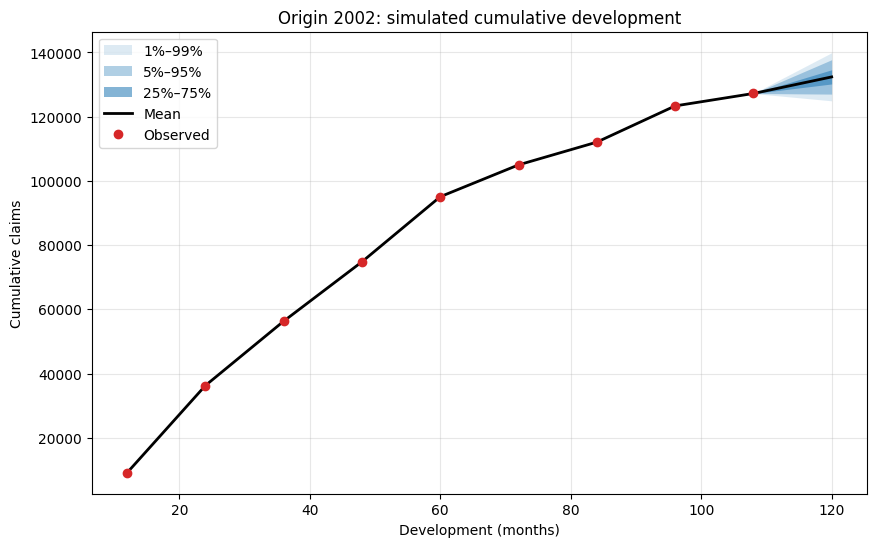

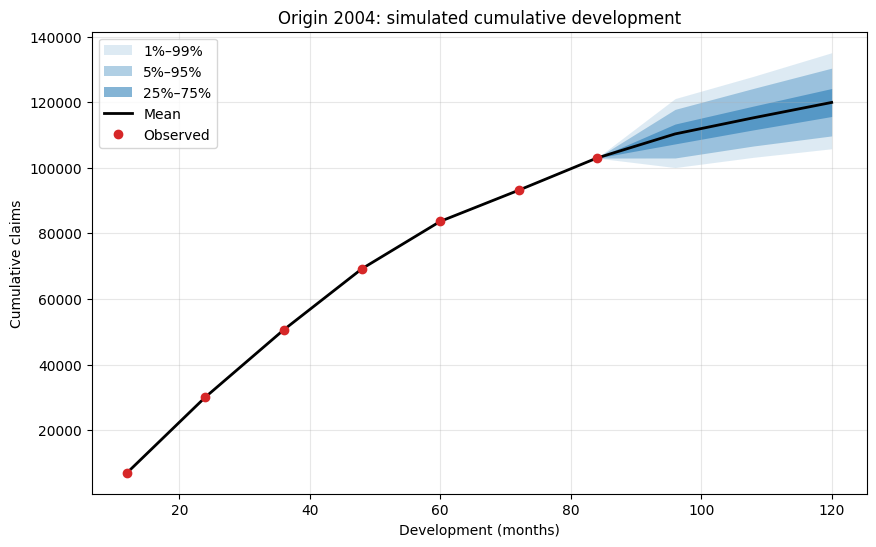

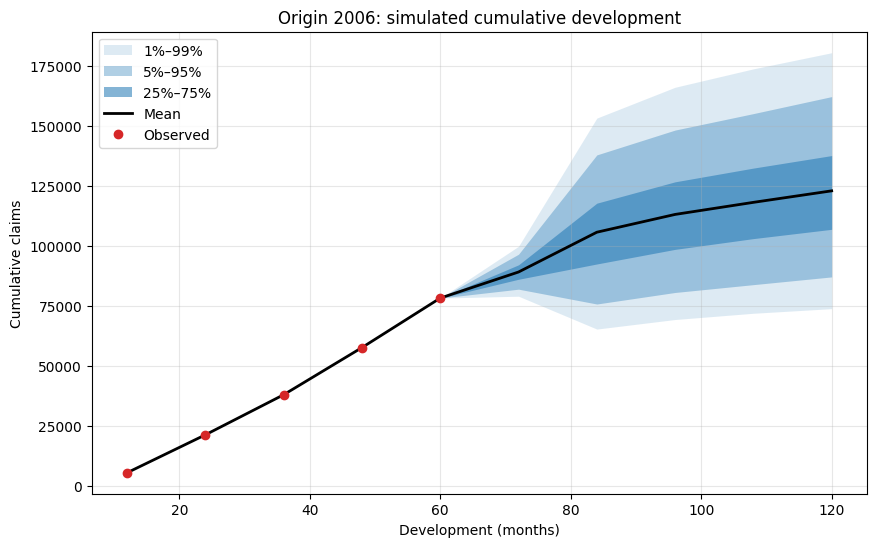

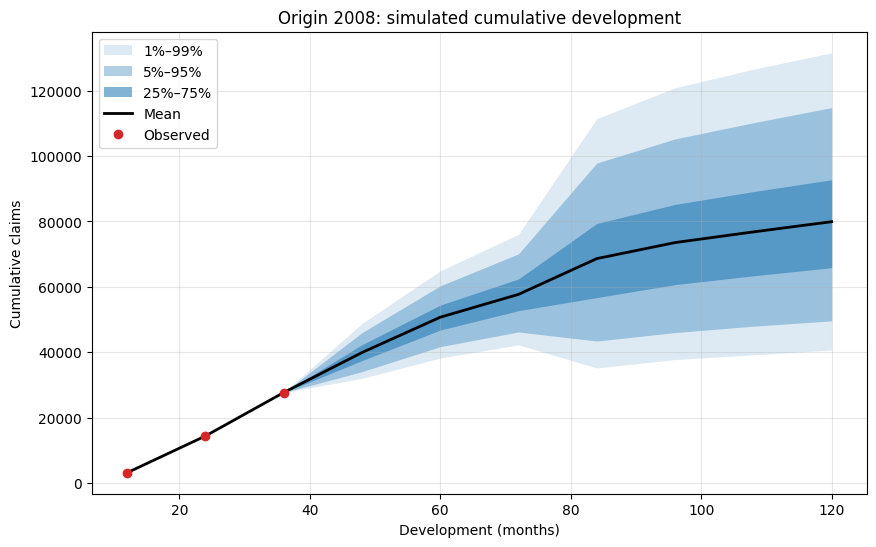

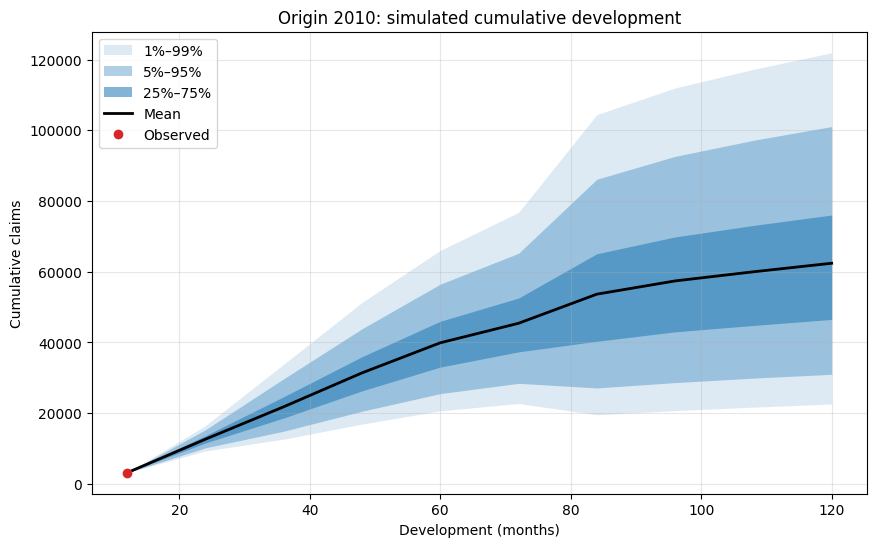

In [4]:
display(boot_all.summary_statistics("reserves").style.format("{:,.0f}"))
display(boot_all.summary_statistics("ultimates").style.format("{:,.0f}"))
for origin in (2002, 2004, 2006, 2008, 2010):
    plot_fan_chart(boot_all, origin)
    plt.show()

**Commentary.** The bootstrap mean, standard deviation and CoV match the analytic Mack results
closely, which is the first check to make. The minimum simulated reserves are negative for the
older origins: Mack's model is a model of link ratios and simulated cumulatives can fall. That
may be acceptable for incurred data but not for paid data. The fan charts widen abruptly at
development period 7, the direct footprint of the sigma spike.

## Step 6: sensitivity analysis — which link ratios matter?

,origin,dev,reserve,reserve_sd,reserve_cov,reserve_diff,sd_diff,cov_diff,reserve_rank,sd_rank,cov_rank
0,2003,72,"289,946","38,076",13.1%,"-41,092","-34,372",-8.8%,1,1,1
1,2003,84,"345,512","68,459",19.8%,"14,474","-3,989",-2.1%,43,2,2
2,2001,60,"323,540","68,955",21.3%,"-7,498","-3,492",-0.6%,4,3,3
3,2003,36,"326,637","71,609",21.9%,"-4,401",-839,0.0%,5,4,24
4,2006,48,"327,556","71,789",21.9%,"-3,482",-659,0.0%,7,5,22
5,2005,48,"327,759","71,903",21.9%,"-3,279",-545,0.1%,8,6,25
6,2007,24,"328,595","72,014",21.9%,"-2,443",-434,0.0%,10,7,21
7,2005,24,"328,310","72,065",22.0%,"-2,728",-383,0.1%,9,8,28
8,2005,12,"330,931","72,319",21.9%,-107,-129,-0.0%,20,9,11
9,2002,84,"322,888","72,325",22.4%,"-8,150",-123,0.5%,3,10,38


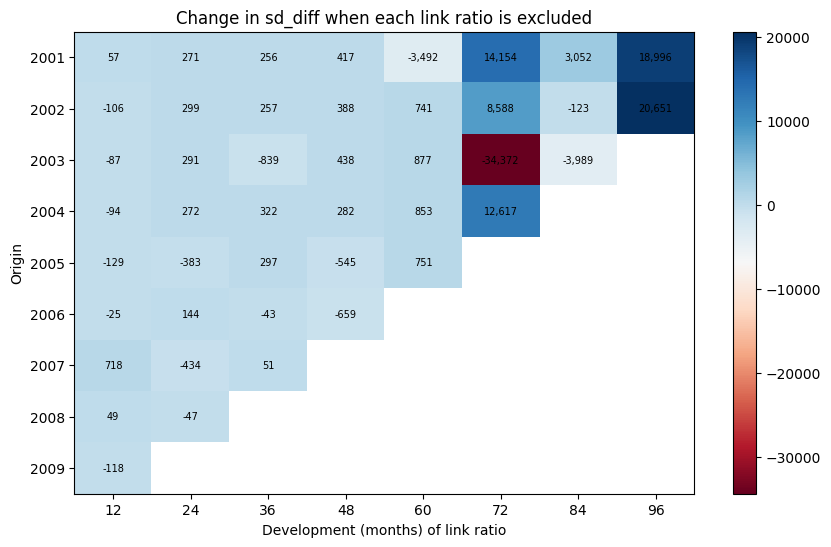

In [5]:
sens = link_ratio_sensitivity(tri)
display(sens.head(10).style.format({"reserve": "{:,.0f}", "reserve_sd": "{:,.0f}", "reserve_cov": "{:.1%}",
                                    "reserve_diff": "{:,.0f}", "sd_diff": "{:,.0f}", "cov_diff": "{:.1%}"}))
plot_sensitivity_heatmap(sens, value="sd_diff")
plt.show()

**Commentary.** Excluding each link ratio in turn and re-applying Mack analytically is a quick
way to find influential points. Dropping the 72->84 ratio of origin 2003 gives the largest
reduction in reserve, standard deviation and CoV by a wide margin; the next most influential
ratio matters far less.

## Step 7: exclude the top three ratios and re-apply Mack analytically

In [6]:
top3 = top_influential(sens, n=3, by="sd")
print("Excluding:", top3)
mack_top3 = mack_analytic_rmsep(tri, drop=top3)
display(mack_top3.to_frame().style.format({"reserve": "{:,.0f}", "sd": "{:,.0f}", "cov": "{:.1%}"}))

Excluding: [('2003', 72), ('2003', 84), ('2001', 60)]


,reserve,sd,cov
2001,0,0,nan%
2002,"5,173","1,574",30.4%
2003,"13,523","3,885",28.7%
2004,"19,390","3,408",17.6%
2005,"27,839","5,201",18.7%
2006,"36,164","5,535",15.3%
2007,"37,297","6,797",18.2%
2008,"46,330","9,307",20.1%
2009,"55,484","14,037",25.3%
2010,"55,247","14,540",26.3%


**Commentary.** With the three most influential ratios excluded the reserve, its standard
deviation and its CoV all fall sharply. Whether any exclusion is justified is the analyst's call;
the point is to know which data points drive the volatility before making it.

## Step 8: residuals and sigma after the exclusions

Mack sigma after exclusions: [26.8  31.1  20.79 15.95  5.4   9.74  3.38  6.43  3.38]


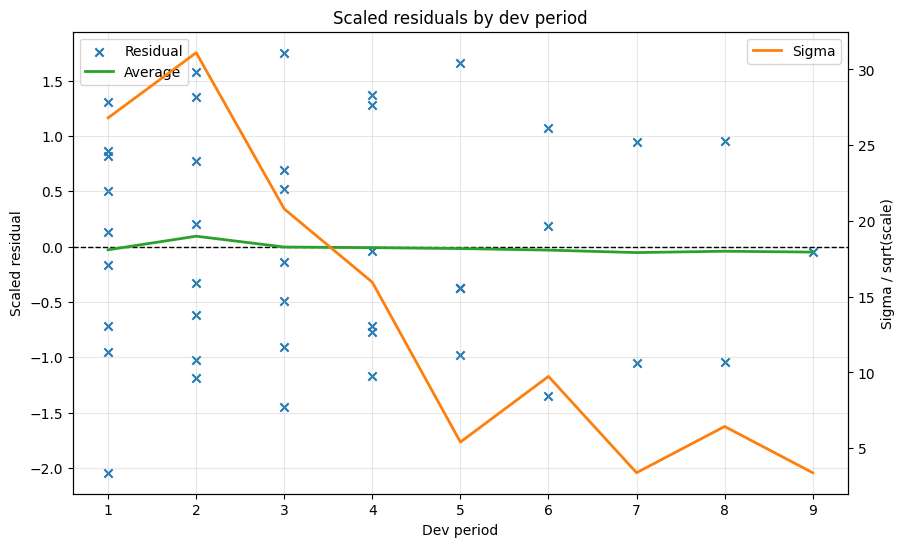

In [7]:
boot_top3 = MackBootstrap(n_sims=10_000, random_seed=100, drop=top3).fit(tri)
print("Mack sigma after exclusions:", np.round(boot_top3.sigma_, 2))
plot_scaled_residuals(boot_top3.scaled_residuals_, by="dev", sigma=boot_top3.sigma_)
plt.show()

**Commentary.** Excluding a ratio also excludes its residual, so sigma at development ratio 6
collapses and the standard deviation of the reserves falls with it.

## Step 9: bootstrap Mack's model after the exclusions

,mean,std,cov,min,0.5%,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.5%,max
2001,0,0,nan,0,0,0,0,0,0,0,0,0,0,0,0,0
2002,"5,176","1,686",0,"-1,771",860,"1,251","2,432","3,015","4,025","5,195","6,315","7,336","7,905","9,154","9,543","12,354"
2003,"13,545","3,989",0,"-1,554","3,184","4,462","7,016","8,391","10,861","13,559","16,232","18,718","20,089","22,804","23,679","29,313"
2004,"19,335","3,458",0,"7,250","10,629","11,521","13,705","14,853","16,960","19,297","21,667","23,783","25,015","27,624","28,429","32,483"
2005,"27,923","5,280",0,"7,053","14,600","15,809","19,188","21,237","24,364","27,913","31,511","34,805","36,687","40,146","41,220","47,211"
2006,"36,159","5,549",0,"17,178","22,573","23,691","27,146","29,055","32,402","36,082","39,774","43,380","45,476","49,447","51,137","57,814"
2007,"37,335","6,813",0,"16,559","21,097","22,449","26,335","28,626","32,586","37,213","41,801","46,331","48,713","53,374","55,601","65,490"
2008,"46,449","9,481",0,"16,272","24,326","26,124","31,656","34,575","39,780","45,942","52,649","58,822","62,569","70,155","73,693","87,782"
2009,"55,518","14,190",0,"13,755","23,481","25,409","33,460","38,239","45,545","54,709","64,698","73,921","79,932","92,322","96,982","119,890"
2010,"55,174","14,671",0,"11,397","23,122","25,768","33,140","37,260","44,928","54,092","64,277","74,472","81,183","93,986","99,418","139,783"


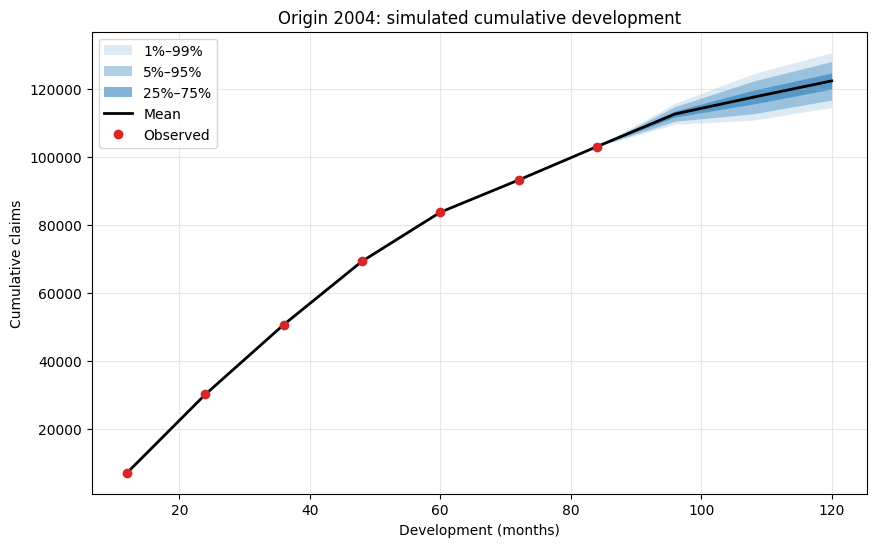

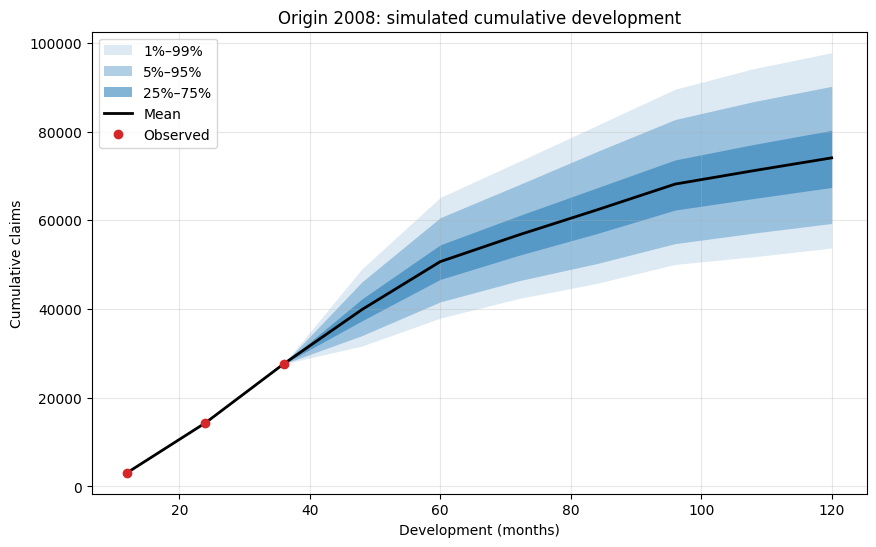

In [8]:
display(boot_top3.summary_statistics("reserves").style.format("{:,.0f}"))
for origin in (2004, 2008):
    plot_fan_chart(boot_top3, origin)
    plt.show()

**Commentary.** The bootstrap again matches the analytic result with the same exclusions, far
fewer simulations produce negative reserves, and the fan charts no longer jump at period 7.

## Step 10: keep all ratios but override sigma

,mean,std,cov,min,0.5%,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.5%,max
2001,0,0,nan,0,0,0,0,0,0,0,0,0,0,0,0,0
2002,"5,156","3,247",1,"-6,575","-3,073","-2,300",-207,995,"2,943","5,150","7,375","9,302","10,430","12,685","13,665","18,250"
2003,"13,526","5,120",0,"-4,803",813,"1,931","5,090","6,965","10,041","13,488","16,978","20,143","22,114","25,364","26,838","34,676"
2004,"16,951","6,250",0,"-4,140","1,450","2,786","6,809","9,046","12,662","16,850","21,114","24,985","27,308","32,183","33,531","41,147"
2005,"34,463","11,947",0,"-10,380","6,190","8,706","15,269","19,243","26,235","34,086","42,268","50,230","54,825","63,355","66,094","81,176"
2006,"44,832","13,253",0,"2,120","13,099","16,151","23,994","28,265","35,602","44,354","53,514","62,335","67,357","77,072","80,127","110,588"
2007,"43,483","11,567",0,"7,282","16,368","18,721","25,147","28,948","35,585","42,936","51,106","58,412","63,137","72,570","76,408","87,196"
2008,"52,083","13,179",0,"15,206","22,393","25,129","31,915","35,788","42,711","51,282","60,695","69,453","74,767","85,463","89,614","110,778"
2009,"61,018","17,074",0,"10,067","23,099","26,107","35,127","40,184","49,095","59,917","71,567","83,360","91,011","106,549","112,061","142,633"
2010,"59,552","17,333",0,"11,598","22,091","25,648","33,847","38,745","47,064","58,098","70,246","82,492","90,198","106,633","112,094","148,687"


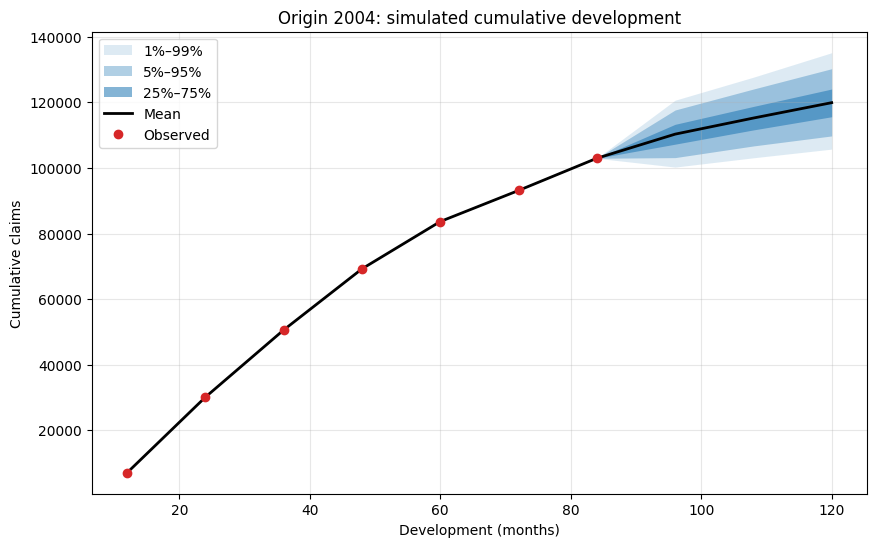

In [9]:
user_sigma = sigma_original.copy()
user_sigma[5] = 13.0  # tame the spike at the 72->84 ratio
boot_user = MackBootstrap(n_sims=10_000, random_seed=100, process_sigma=user_sigma).fit(tri)
display(boot_user.summary_statistics("reserves").style.format("{:,.0f}"))
plot_fan_chart(boot_user, 2004)
plt.show()

**Commentary.** Overriding the variance parameter leaves the mean unchanged (up to simulation
error) while reducing the standard deviation and CoV. User-defined sigmas are an alternative to
exclusions for controlling volatility once its drivers are understood.

## Step 11: the over-dispersed Poisson model with non-constant scale

ODP sqrt(scale) by development period: [ 16.1  32.4  26.9  14.1  30.4  38.  116.5  46.   29.9  29.9]


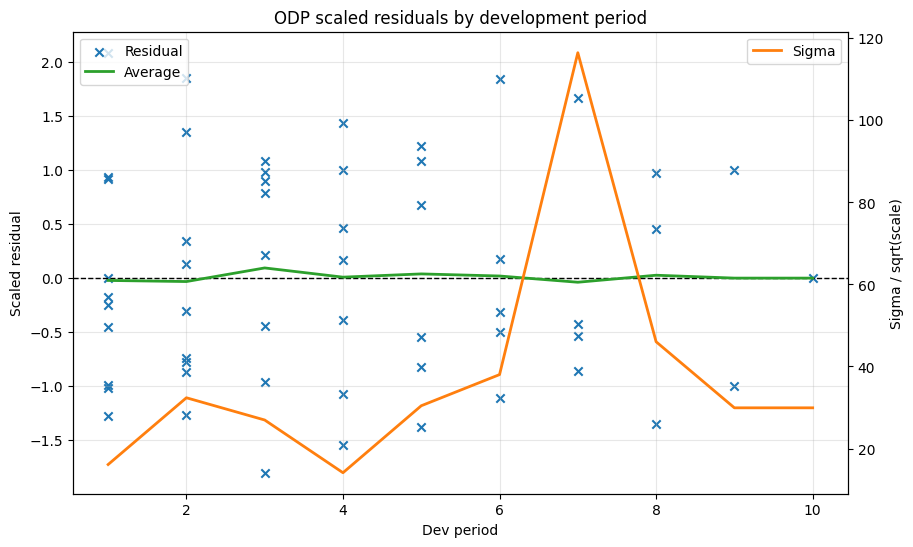

,mean,std,cov,min,0.5%,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.5%,max
2001,0,0,nan,0,0,0,0,0,0,0,0,0,0,0,0,0
2002,"5,257","3,825",1,1,215,346,920,"1,395","2,539","4,377","6,973","10,161","12,663","18,543","20,700","31,874"
2003,"13,790","6,325",0,927,"3,114","3,596","5,584","6,775","9,274","12,747","17,118","22,104","25,601","34,006","36,882","55,967"
2004,"16,927","6,704",0,"2,192","4,740","5,514","7,731","9,182","12,035","16,034","20,769","25,776","29,227","37,085","40,639","57,628"
2005,"35,058","17,784",1,"4,080","8,485","9,672","13,729","16,600","22,565","31,371","43,454","58,187","68,724","94,596","103,968","165,290"
2006,"44,866","18,347",0,"8,947","15,285","16,555","21,518","24,685","31,710","41,692","53,843","68,817","79,484","104,045","113,563","161,818"
2007,"43,627","17,111",0,"8,782","14,802","16,380","21,821","25,237","31,598","40,418","52,370","66,215","75,226","97,368","109,425","161,934"
2008,"52,470","19,691",0,"10,322","19,277","20,954","27,012","30,827","38,465","49,119","62,766","78,370","89,503","112,914","126,035","187,574"
2009,"61,287","25,607",0,"11,159","18,926","21,121","28,468","33,381","43,139","56,704","74,606","95,142","110,038","139,303","154,772","216,938"
2010,"61,586","48,721",1,"1,768","6,594","7,897","13,734","18,414","29,297","48,120","78,489","120,767","155,836","240,852","284,419","677,761"


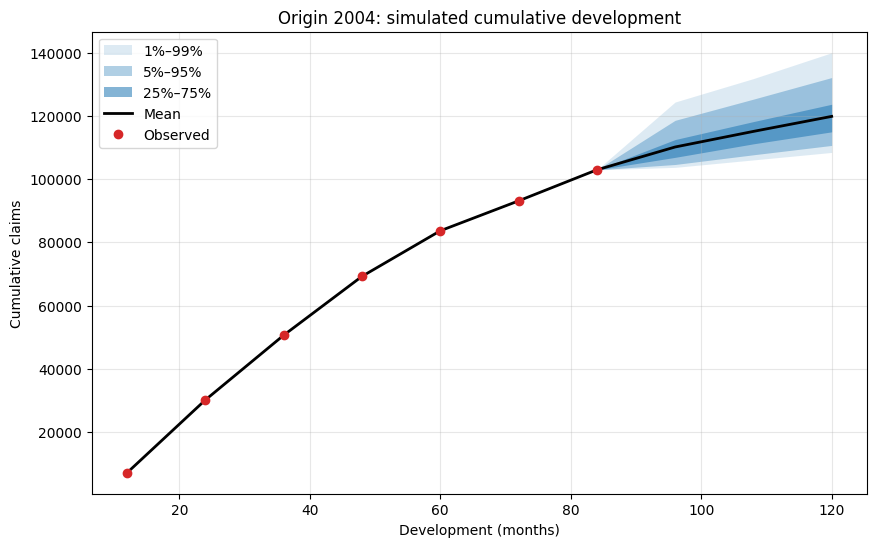

In [10]:
odp_all = CorrelatedBootstrapChainLadder(n_sims=10_000, rho=0.0, scale="nonconstant",
                                          parametric_dist="lognormal", random_seed=100).fit(tri)
sqrt_scale_original = np.sqrt(odp_all.sampler_.scale_by_dev_)
print("ODP sqrt(scale) by development period:", np.round(sqrt_scale_original, 1))
plot_scaled_residuals(odp_all.sampler_.standardized_residuals_ / np.where(sqrt_scale_original > 0, sqrt_scale_original, np.nan),
                      by="dev", sigma=sqrt_scale_original, title="ODP scaled residuals by development period")
plt.show()
display(odp_all.summary_statistics("reserves").style.format("{:,.0f}"))
plot_fan_chart(odp_all, 2004)
plt.show()

**Commentary.** The ODP model is a model of incremental amounts, so the residual triangle is
10×10 and the spike now sits at development period 7 (the cell, not the ratio). With
non-constant scale the total standard deviation is close to Mack's, as expected, but because
future increments are drawn from a positive distribution the minimum reserves stay positive.

## Step 12: ODP after excluding the influential ratios

ODP sqrt(scale) after exclusions: [14.7 29.1 30.  17.3 35.4 18.4 23.3  8.6 29.9  8.6]


,mean,std,cov,min,0.5%,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.5%,max
2001,0,0,nan,0,0,0,0,0,0,0,0,0,0,0,0,0
2002,"5,325","4,441",1,92,537,663,"1,159","1,530","2,454","4,084","6,686","10,617","13,739","22,891","25,719","54,521"
2003,"13,907","7,725",1,"1,076","2,648","3,122","4,817","6,045","8,499","12,304","17,491","23,488","28,119","40,984","47,165","73,527"
2004,"19,689","7,389",0,"3,708","7,291","7,883","10,229","11,603","14,500","18,528","23,331","29,300","33,417","44,364","48,222","64,295"
2005,"28,184","9,250",0,"8,386","11,661","12,633","15,808","17,797","21,682","26,755","33,127","40,266","45,367","56,537","61,585","86,423"
2006,"36,622","11,139",0,"11,545","16,100","17,352","21,557","23,941","28,782","35,009","42,700","51,192","57,355","70,657","74,735","112,911"
2007,"37,625","12,861",0,"10,065","14,465","15,720","20,164","23,072","28,390","35,761","44,664","54,532","61,501","76,846","83,026","111,212"
2008,"47,232","18,372",0,"9,706","15,917","17,468","23,352","26,975","34,265","44,182","56,779","71,053","81,896","104,548","112,726","168,462"
2009,"56,312","28,293",1,"7,174","14,737","16,297","23,111","27,264","36,746","50,473","68,946","92,732","109,129","155,053","173,158","340,526"
2010,"58,446","62,164",1,608,"3,353","4,703","8,792","12,632","21,633","39,664","73,503","122,559","172,660","310,491","366,859","1,102,800"


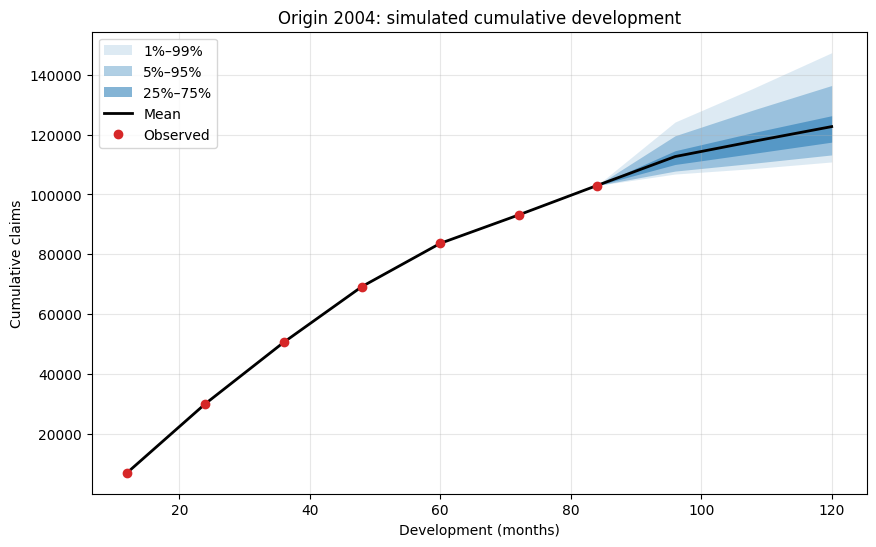

In [11]:
odp_top3 = CorrelatedBootstrapChainLadder(n_sims=10_000, rho=0.0, scale="nonconstant",
                                           parametric_dist="lognormal", random_seed=100, drop=top3).fit(tri)
print("ODP sqrt(scale) after exclusions:", np.round(np.sqrt(odp_top3.sampler_.scale_by_dev_), 1))
display(odp_top3.summary_statistics("reserves").style.format("{:,.0f}"))
plot_fan_chart(odp_top3, 2004)
plt.show()

**Commentary.** The same ratios are influential under both models. Dropping the 72→84 ratio of
origin 2003 removes the development-period-7 residual from the scale estimate, and the ODP
standard deviation falls in line with Mack's with the same exclusions.

## Step 13: ODP with a user-defined scale

In [12]:
user_scale = odp_all.sampler_.scale_by_dev_.copy()
user_scale[6] = 40.0 ** 2
odp_user = CorrelatedBootstrapChainLadder(n_sims=10_000, rho=0.0, scale="nonconstant",
                                           parametric_dist="lognormal", random_seed=100,
                                           process_scale=user_scale).fit(tri)
display(odp_user.summary_statistics("reserves").style.format("{:,.0f}"))

,mean,std,cov,min,0.5%,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.5%,max
2001,0,0,nan,0,0,0,0,0,0,0,0,0,0,0,0,0
2002,"5,253","3,830",1,4,202,329,952,"1,407","2,547","4,340","6,997","10,265","12,593","17,968","20,886","39,739"
2003,"13,686","6,190",0,"1,728","3,087","3,590","5,459","6,735","9,248","12,768","17,037","21,706","25,084","32,822","35,695","53,669"
2004,"17,000","6,829",0,"1,228","4,445","5,308","7,581","9,064","12,143","16,064","20,794","26,091","29,612","37,031","40,357","62,912"
2005,"34,904","10,329",0,"7,865","14,370","15,511","20,034","22,688","27,524","33,800","41,071","48,399","53,384","63,447","67,712","100,493"
2006,"45,206","12,175",0,"13,928","20,304","22,014","27,453","30,653","36,481","43,944","52,786","61,189","67,273","78,260","82,474","117,915"
2007,"43,622","12,519",0,"9,884","18,161","19,922","25,365","28,653","34,728","42,405","51,054","60,069","65,994","78,634","84,286","106,085"
2008,"52,457","15,979",0,"11,859","21,576","23,557","30,265","34,029","41,080","50,447","61,706","73,742","82,032","98,849","104,597","132,695"
2009,"61,350","23,189",0,"14,451","21,893","23,698","30,751","35,589","44,839","57,572","73,649","91,955","104,280","132,715","147,153","259,390"
2010,"61,516","47,702",1,479,"7,078","8,606","15,018","19,781","30,087","48,477","77,930","116,778","151,214","239,862","286,609","657,633"


**Commentary.** As with Mack's model, a user-defined scale leaves the mean alone and reduces the
spread. Use it carefully, and only after the drivers of volatility are understood.

## Step 14: compare and select

In [13]:
rows = {
    "Mack, all ratios": boot_all, "Mack, top-3 excluded": boot_top3, "Mack, user sigma": boot_user,
    "ODP, all ratios": odp_all, "ODP, top-3 excluded": odp_top3, "ODP, user scale": odp_user,
}
compare = pd.DataFrame({
    name: {"mean": m.total_summary().total_reserve_mean, "sd": m.total_summary().total_reserve_stddev,
           "cov": m.total_summary().total_reserve_cv, "p99.5": m.total_summary().total_reserve_99_5th_percentile}
    for name, m in rows.items()
}).T
display(compare.style.format({"mean": "{:,.0f}", "sd": "{:,.0f}", "cov": "{:.1%}", "p99.5": "{:,.0f}"}))

,mean,sd,cov,p99.5
"Mack, all ratios","330,846","68,699",20.8%,"517,700"
"Mack, top-3 excluded","296,614","30,771",10.4%,"379,717"
"Mack, user sigma","331,062","56,259",17.0%,"487,239"
"ODP, all ratios","334,869","75,135",22.4%,"601,166"
"ODP, top-3 excluded","303,342","87,184",28.7%,"665,792"
"ODP, user scale","334,993","69,706",20.8%,"589,025"


**Commentary.** Only now, knowing what drives the volatility and how each model behaves, is the
analyst placed to choose a model, decide on exclusions and decide whether to override the
variance parameters. Tail extrapolation is a common further step and is not covered here.

## Step 15: scale to target ultimates

In [14]:
selected = odp_top3
origins = list(selected.reserves_posterior_.origin.values)
paid = selected._paid_to_date().reindex(origins)
target_ultimates = paid + 1.1 * selected.ibnr_["mean"]   # illustrative target only
methods = {o: ("additive" if k < 5 else "multiplicative") for k, o in enumerate(origins)}
scaled = selected.scale_to_target(target_ultimates, method=methods)
display(selected.summary_statistics("reserves")[["mean", "std", "cov"]].style.format({"mean": "{:,.0f}", "std": "{:,.0f}", "cov": "{:.1%}"}))
display(scaled.summary_statistics("reserves")[["mean", "std", "cov"]].style.format({"mean": "{:,.0f}", "std": "{:,.0f}", "cov": "{:.1%}"}))

,mean,std,cov
2001,0,0,nan%
2002,"5,325","4,441",83.4%
2003,"13,907","7,725",55.5%
2004,"19,689","7,389",37.5%
2005,"28,184","9,250",32.8%
2006,"36,622","11,139",30.4%
2007,"37,625","12,861",34.2%
2008,"47,232","18,372",38.9%
2009,"56,312","28,293",50.2%
2010,"58,446","62,164",106.4%


,mean,std,cov
2001,0,0,nan%
2002,"5,858","4,441",75.8%
2003,"15,298","7,725",50.5%
2004,"21,658","7,389",34.1%
2005,"31,003","9,250",29.8%
2006,"40,284","12,253",30.4%
2007,"41,387","14,147",34.2%
2008,"51,955","20,209",38.9%
2009,"61,943","31,123",50.2%
2010,"64,290","68,380",106.4%


**Commentary.** Reserving teams rarely book the mean of a simple chain-ladder bootstrap, so the
distribution is usually shifted to a target. Additive scaling keeps the absolute standard
deviation and changes the CoV; multiplicative scaling keeps the CoV and changes the standard
deviation. The method can be chosen per origin. If a lot of scaling is needed, stop and
investigate rather than scale.

### Common errors and fallacies (paraphrased from the source)

* There is no such thing as "the" bootstrap model. Bootstrapping is a procedure applied to a
  specified statistical model; say which model, and prefer non-constant scale for ODP.
* Mack's model tolerates negative increments and factors below one and suits incurred data; the
  ODP model needs factors above one and gives positive simulated increments.
* An incurred bootstrap gives a distribution of IBNR+IBNER and of ultimates. To compare CoVs
  with a paid analysis, subtract the latest paid from each simulated ultimate
  (`incurred_to_paid`).
* Parametric bootstrapping simulates pseudo-data directly from a parametric distribution given
  its mean and variance. Simulating residuals from a Normal and inverting them is not parametric
  bootstrapping.

## Epilogue: the one-year view

In [15]:
cdr = claims_development_result(odp_top3)
one_year = cdr.summary().query("future_period == 1").set_index("origin")
lifetime_sd = odp_top3.summary_statistics("reserves")["std"]
one_year["lifetime_sd"] = lifetime_sd.reindex(one_year.index).values
one_year["cdr_sd_ratio"] = one_year["sd"] / one_year["lifetime_sd"]
display(one_year[["sd", "lifetime_sd", "cdr_sd_ratio", "var"]].style.format({"sd": "{:,.0f}", "lifetime_sd": "{:,.0f}", "cdr_sd_ratio": "{:.0%}", "var": "{:,.0f}"}))

,sd,lifetime_sd,cdr_sd_ratio,var
origin,,,,
2001,0,0,nan%,0
2002,"4,441","4,441",100%,"20,394"
2003,"5,844","7,725",76%,"23,796"
2004,"4,714","7,389",64%,"16,812"
2005,"5,271","9,250",57%,"18,494"
2006,"5,742","11,139",52%,"20,024"
2007,"8,807","12,861",68%,"29,554"
2008,"10,478","18,372",57%,"37,479"
2009,"18,682","28,293",66%,"71,351"


The one-year Claims Development Result re-reserves each simulated next diagonal (the
"actuary in the box") and is the basis for Solvency II reserve risk. See `claims_development_result`,
`bayesianchainladder.riskmeasures` and the England, Verrall & Wüthrich (2019) example in
[https://github.com/DrPeterEngland/StochasticReserving](https://github.com/DrPeterEngland/StochasticReserving) for cost-of-capital risk margins and IFRS 17 risk adjustments.